# Phase 1 — ER queueing baseline (`ER_Phase2_Group_12.csv`)

**Task 1:** λ, μ; histograms; exponential / lognormal checks; **Cv** (service).  
**Task 2:** **M/M/5** and **M/G/5** (\(L_q\), \(W_q\)).  
**Task 3:** **PASTA** — time fraction **\(p_n\)** (all 5 doctors busy) vs arrival fraction **\(a_n\)**, vs **Erlang C**.  
**Task 4:** **Warm-up** — simulated **M/M/5** running mean \(W_q\) for **\(\rho \in \{0.7,0.8,0.95\}\)** (longer run for high \(\rho\); see code).

**Data note:** `Arrival_Clock` uses day rollover in row order. **Priority** ignored is ignored here for Phase 1.

### Prepared by Erdoğan Kocabaş (2021402183) & Berru Selcan Cocen (2021402003)

## Library Installations

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import expon, lognorm, kstest
from datetime import datetime
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Task 1: Data Inference & Distribution Fitting
## Initialization

In [2]:
file_path = '/Users/erdogan.kocabas/Desktop/IE493/ER_Phase2_Group_12.csv'
df = pd.read_csv(file_path, sep=';', skipinitialspace=True)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
if 'Priority' in df.columns:
    df = df.drop(columns=['Priority'])

df['Service_Required_Min'] = pd.to_numeric(
    df['Service_Required_Min'].astype(str).str.replace(';', ''),
    errors='coerce',
)
df = df.dropna(subset=['Service_Required_Min']).reset_index(drop=True)


def sequential_arrival_datetimes(arrival_series: pd.Series) -> pd.Series:
    """Build a true timeline: when wall-clock goes backward (e.g. 23:59 → 00:04), advance one day."""
    base = pd.Timestamp('2026-01-01')
    day = 0
    prev_sec = None
    out = []
    for t in arrival_series:
        parts = str(t).strip().split(':')
        h, m, s = int(parts[0]), int(parts[1]), int(parts[2]) if len(parts) > 2 else 0
        sec = h * 3600 + m * 60 + s
        if prev_sec is not None and sec < prev_sec:
            day += 1
        prev_sec = sec
        out.append(base + pd.Timedelta(days=day) + pd.Timedelta(seconds=sec))
    return pd.Series(out, index=arrival_series.index)


df['Arrival_Datetime'] = sequential_arrival_datetimes(df['Arrival_Clock'])
# Keep CSV row order (chronological arrivals per dataset); do not sort by time-of-day only.
df.head()

,Patient_ID,Arrival_Clock,Service_Required_Min,Arrival_Datetime
0,1000,08:00:41,10.45,2026-01-01 08:00:41
1,1001,08:11:00,19.92,2026-01-01 08:11:00
2,1002,08:11:01,8.08,2026-01-01 08:11:01
3,1003,08:13:45,11.69,2026-01-01 08:13:45
4,1004,08:14:21,12.90,2026-01-01 08:14:21


## Parameter Estimation

In [3]:
# Assumptions (Phase 1 brief): ER empty at 08:00; 5 identical doctors; FCFS; infinite waiting room;
# steady-state M/M/c and M/G/c formulas apply (λ < c·μ).

ER_OPEN = pd.Timestamp('2026-01-01 08:00:00')  # same calendar anchor as Arrival_Datetime

inter_arrival_times = df['Arrival_Datetime'].diff().dt.total_seconds() / 60
inter_arrival_times.iloc[0] = (df['Arrival_Datetime'].iloc[0] - ER_OPEN).total_seconds() / 60

mean_inter_arrival = inter_arrival_times.mean()
lambda_rate = 1 / mean_inter_arrival
lambda_rate_per_hour = lambda_rate * 60

mean_service = df['Service_Required_Min'].mean()
service_std = df['Service_Required_Min'].std(ddof=1)
mu_rate = 1 / mean_service
mu_rate_per_hour = mu_rate * 60
cv_service = service_std / mean_service
cv_service_sq = cv_service ** 2

c = 5
rho = lambda_rate / (c * mu_rate)
a = lambda_rate / mu_rate  # offered load (Erlangs)

obs_hours = (df['Arrival_Datetime'].iloc[-1] - ER_OPEN).total_seconds() / 3600
print(f'Patients n = {len(df)}, observation horizon (08:00 → last arrival) ≈ {obs_hours:.2f} h')
print(f'mean_interarrival (incl. first gap from 08:00) = {mean_inter_arrival:.4f} min')
print(f'λ = {lambda_rate:.6f} patients/min = {lambda_rate_per_hour:.2f} patients/h')
print(f'mean service E[S] = {mean_service:.4f} min, μ = {mu_rate:.6f} patients/min per doctor = {mu_rate_per_hour:.2f}/h')
print(f'Cv(service) = σ/E[S] = {cv_service:.4f}, Cv² = {cv_service_sq:.4f}')
print(f'Utilization ρ = λ/(c·μ) = {rho:.4f} (offered load a = λ/μ = {a:.4f} Erlangs)')

Patients n = 1000, observation horizon (08:00 → last arrival) ≈ 67.98 h
mean_interarrival (incl. first gap from 08:00) = 4.0785 min
λ = 0.245186 patients/min = 14.71 patients/h
mean service E[S] = 15.4622 min, μ = 0.064674 patients/min per doctor = 3.88/h
Cv(service) = σ/E[S] = 0.3900, Cv² = 0.1521
Utilization ρ = λ/(c·μ) = 0.7582 (offered load a = λ/μ = 3.7911 Erlangs)


### Empirical FCFS queue (5 doctors, infinite buffer)

Uses the **same** arrival timestamps and `Service_Required_Min` as the dataset (no priority). Each patient joins the queue at `Arrival_Datetime`; the next available doctor starts service at `max(arrival, doctor_free_time)`.

In [4]:
doctor_free = np.zeros(c)  # minutes after ER_OPEN
wait_min = []
svc_start_min = []
svc_end_min = []
t_arr_min = []

for _, row in df.iterrows():
    t_arr = (row['Arrival_Datetime'] - ER_OPEN).total_seconds() / 60
    svc = row['Service_Required_Min']
    j = int(np.argmin(doctor_free))
    start = max(t_arr, doctor_free[j])
    end = start + svc
    t_arr_min.append(t_arr)
    wait_min.append(start - t_arr)
    svc_start_min.append(start)
    svc_end_min.append(end)
    doctor_free[j] = end

t_arr_min = np.array(t_arr_min)
svc_start_min = np.array(svc_start_min)
svc_end_min = np.array(svc_end_min)
wait_min = np.array(wait_min)
Wq_empirical = wait_min.mean()
Lq_empirical_ll = lambda_rate * Wq_empirical  # Little: Lq ≈ λ Wq at estimated λ

print(f'Empirical FCFS (n={len(wait_min)}): mean Wq = {Wq_empirical:.4f} min')
print(f'Implied Lq via Little (λ̂ Wq): {Lq_empirical_ll:.4f} patients')

Empirical FCFS (n=1000): mean Wq = 3.8850 min
Implied Lq via Little (λ̂ Wq): 0.9525 patients


## Goodness of fit tests

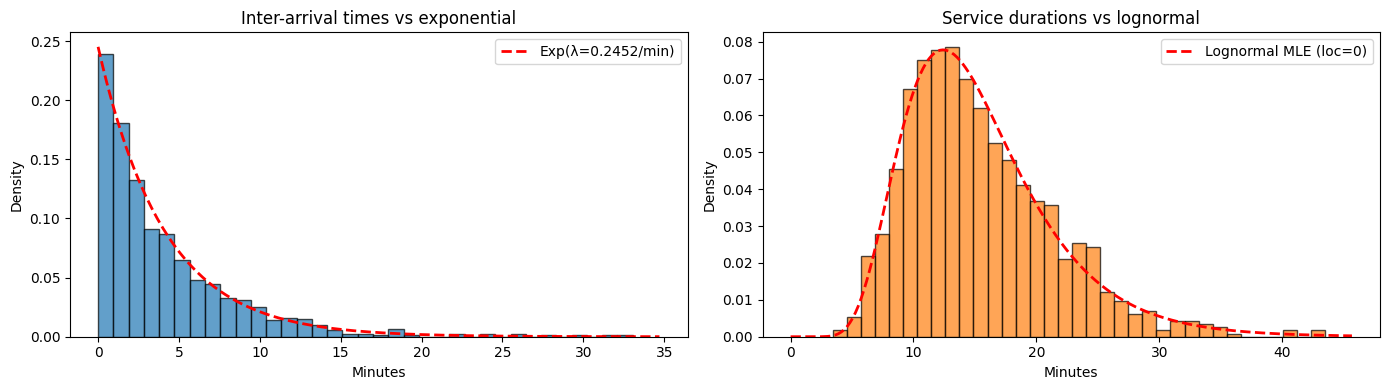

KS test: inter-arrivals ~ Exponential(0, mean): statistic = 0.0306 , p-value = 0.3016482430152796
KS test: service ~ Lognormal(s,0,scale): statistic = 0.0207 , p-value = 0.7746051541497319


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(inter_arrival_times, bins=35, density=True, alpha=0.7, color='tab:blue', edgecolor='black')
xarr = np.linspace(0, inter_arrival_times.max() * 1.05, 200)
axes[0].plot(xarr, expon.pdf(xarr, scale=mean_inter_arrival), 'r--', lw=2, label=f'Exp(λ={1/mean_inter_arrival:.4f}/min)')
axes[0].set_title('Inter-arrival times vs exponential')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].hist(df['Service_Required_Min'], bins=35, density=True, alpha=0.7, color='tab:orange', edgecolor='black')
shape, loc, scale = lognorm.fit(df['Service_Required_Min'], floc=0)
xsvc = np.linspace(1e-6, df['Service_Required_Min'].max() * 1.05, 200)
axes[1].plot(xsvc, lognorm.pdf(xsvc, shape, loc=loc, scale=scale), 'r--', lw=2, label='Lognormal MLE (loc=0)')
axes[1].set_title('Service durations vs lognormal')
axes[1].set_xlabel('Minutes')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

ks_ia = kstest(inter_arrival_times, 'expon', args=(0, mean_inter_arrival))
ks_sv = kstest(df['Service_Required_Min'], 'lognorm', args=(shape, loc, scale))
print('KS test: inter-arrivals ~ Exponential(0, mean): statistic =', round(ks_ia.statistic, 4), ', p-value =', ks_ia.pvalue)
print('KS test: service ~ Lognormal(s,0,scale): statistic =', round(ks_sv.statistic, 4), ', p-value =', ks_sv.pvalue)

# Task 2: Theoretical Modelling

In [6]:
from math import factorial


def erlang_delay_prob(a, c):
    """Erlang C: probability an arrival waits (all c servers busy). Requires a < c."""
    arr = sum(a**n / factorial(n) for n in range(c))
    num = a**c / factorial(c) * (c / (c - a))
    return num / (arr + num)


# M/M/c: Lq = P(wait) * a / (c * (1-ρ)); Wq = Lq / λ; Little's law consistent
if rho >= 1:
    raise ValueError('System unstable: need λ < c·μ for steady-state M/M/c (ρ must be < 1).')

C_erlang = erlang_delay_prob(a, c)
Lq_mm = C_erlang * a / (c * (1 - rho))
Wq_mm = Lq_mm / lambda_rate
Ws_mm = Wq_mm + 1 / mu_rate

# Kingman / VUT heavy-traffic style correction for M/G/c (Poisson arrivals ⇒ Ca² = 1):
# Wq(M/G/c) ≈ Wq(M/M/c) * (Cs² + Ca²) / 2  with Ca=1  ⇒  factor (Cv² + 1) / 2
kingman_factor = (cv_service_sq + 1) / 2
Wq_mg = kingman_factor * Wq_mm
Lq_mg = lambda_rate * Wq_mg
Ws_mg = Wq_mg + 1 / mu_rate

print('--- M/M/5 (exponential service, Cv = 1) ---')
print(f'Erlang C (P(wait)) = {C_erlang:.6f}')
print(f'Lq = {Lq_mm:.6f} patients')
print(f'Wq = {Wq_mm:.4f} min')
print(f'Ws = Wq + 1/μ = {Ws_mm:.4f} min')

print('\n--- M/G/5 (Kingman-style adjustment for service variability) ---')
print(f'Factor (Cv² + Ca²)/2 with Ca²=1: {kingman_factor:.6f}')
print(f'Lq ≈ {Lq_mg:.6f} patients')
print(f'Wq ≈ {Wq_mg:.4f} min')
print(f'Ws ≈ {Ws_mg:.4f} min')

--- M/M/5 (exponential service, Cv = 1) ---
Erlang C (P(wait)) = 0.476402
Lq = 1.494003 patients
Wq = 6.0933 min
Ws = Wq + 1/μ = 21.5555 min

--- M/G/5 (Kingman-style adjustment for service variability) ---
Factor (Cv² + Ca²)/2 with Ca²=1: 0.576040
Lq ≈ 0.860606 patients
Wq ≈ 3.5100 min
Ws ≈ 18.9722 min


## M/M/5 and M/G/5 Modelling

In [7]:
summary = pd.DataFrame({
    'Quantity': [
        'λ (patients/min)',
        'μ per doctor (patients/min)',
        'ρ = λ/(5μ)',
        'Cv(service)',
        'Lq (patients)',
        'Wq (min)',
    ],
    'From data (observed / estimated)': [
        f'{lambda_rate:.6f}',
        f'{mu_rate:.6f}',
        f'{rho:.4f}',
        f'{cv_service:.4f}',
        f'{Lq_empirical_ll:.4f} (λ̂·W̄q, FCFS trace)',
        f'{Wq_empirical:.4f} (FCFS trace, 5 doctors)',
    ],
    'M/M/5 (theory, exp. service)': [
        f'{lambda_rate:.6f}',
        f'{mu_rate:.6f}',
        f'{rho:.4f}',
        '1.000 (assumed)',
        f'{Lq_mm:.4f}',
        f'{Wq_mm:.4f}',
    ],
    'M/G/5 (Kingman-style)': [
        f'{lambda_rate:.6f}',
        f'{mu_rate:.6f}',
        f'{rho:.4f}',
        f'{cv_service:.4f}',
        f'{Lq_mg:.4f}',
        f'{Wq_mg:.4f}',
    ],
})
summary

,Quantity,From data (observed / estimated),"M/M/5 (theory, exp. service)",M/G/5 (Kingman-style)
0,λ (patients/min),0.245186,0.245186,0.245186
1,μ per doctor (patients/min),0.064674,0.064674,0.064674
2,ρ = λ/(5μ),0.7582,0.7582,0.7582
3,Cv(service),0.3900,1.000 (assumed),0.3900
4,Lq (patients),"0.9525 (λ̂·W̄q, FCFS trace)",1.4940,0.8606
5,Wq (min),"3.8850 (FCFS trace, 5 doctors)",6.0933,3.5100


# Task 3: PASTA Property

The next cell **computes and displays** \(p_n\) and \(a_n\) in tables, then a **bar chart** comparing them to **Erlang C**. It is **self-contained** (only needs `df` + `ER_OPEN`). The markdown cell **after** the code explains **why \(a_n\) and \(p_n\) are not exactly equal** in our data.

**Definitions (5 parallel doctors, FCFS):**  
- **All doctors occupied** ⇔ at least **5** patients are currently **in service** (i.e. number in service = 5).

- **\(p_n\) (time average):** share of simulation time over \([T_0, T_1]\) during which all 5 doctors are busy. We take \(T_0\) = 08:00 (empty system) and \(T_1\) = last service completion so the timeline matches the trace.

- **\(a_n\) (arrival average):** among arriving patients, the fraction who **upon arrival** see **5 other** patients already in service (so all servers busy before they are assigned a doctor). For patient \(k\) at arrival time \(t_k\), count other patients \(j\) with service interval \([s_j, e_j)\) covering \(t_k\): \(s_j \le t_k < e_j\) (excluding \(k\), who is not yet in service).

**PASTA:** For an **M/M/c** queue with **Poisson arrivals**, arrivals see the system at a **random time**, so the **arrival-time** fraction \(a_n\) should match the **time-average** fraction \(p_n\) (both equal **Erlang C**, the probability all servers are busy at a random time). Our data are **not** perfect Poisson, so \(a_n\) and \(p_n\) may **differ slightly**; we still compare them and optionally to **Erlang C** from the M/M/5 model.

,quantity,value (fraction),value (%)
0,p_n — time average: fraction of time all 5 doc...,0.472105,47.210498
1,a_n — arrival average: fraction of arrivals wh...,0.483000,48.300000


,metric,fraction,percent
0,p_n,0.472105,47.210498
1,a_n,0.483000,48.300000
2,Erlang C (M/M/5 theory),0.476402,47.640238
3,a_n − p_n,0.010895,1.089502
4,|a_n − p_n|,0.010895,1.089502


Arrivals with all 5 busy: 483 / 1000

Observation length T_high − T_low = 4116.0267 min (68.6004 h)
Time all 5 busy (minutes): 1943.196667


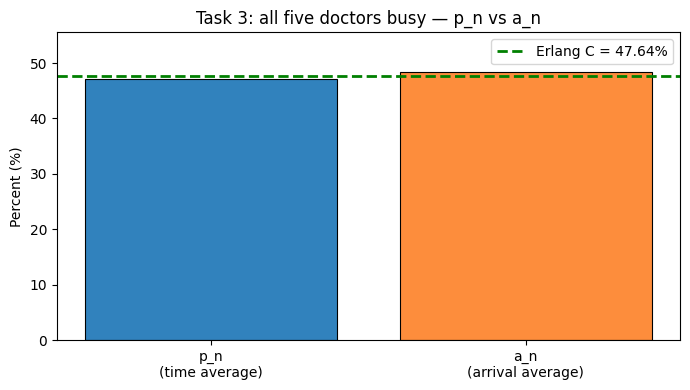

In [14]:
# Task 3 — PASTA: show p_n vs a_n (self-contained: only needs `df`, `ER_OPEN`, numpy, pandas)
# Rebuilds FCFS with 5 doctors so you do not need to run a separate FCFS cell first.

from math import factorial
import matplotlib.pyplot as plt
from IPython.display import display

if "df" not in globals() or "ER_OPEN" not in globals():
    raise RuntimeError("Run data load + parameter cells first (need `df` with Arrival_Datetime and `ER_OPEN`).")

c = 5
n_pat = len(df)

t_arr_min = (df["Arrival_Datetime"] - ER_OPEN).dt.total_seconds().to_numpy(dtype=float) / 60.0
svc_min = df["Service_Required_Min"].to_numpy(dtype=float)

doctor_free = np.zeros(c, dtype=float)
s_start = np.empty(n_pat, dtype=float)
s_end = np.empty(n_pat, dtype=float)
for i in range(n_pat):
    t_a = t_arr_min[i]
    sv = float(svc_min[i])
    j = int(np.argmin(doctor_free))
    st = max(t_a, doctor_free[j])
    en = st + sv
    s_start[i] = st
    s_end[i] = en
    doctor_free[j] = en

svc_start_min = s_start
svc_end_min = s_end

# p_n
T_low, T_high = 0.0, float(s_end.max())
bps = np.unique(np.concatenate([np.array([T_low, T_high], dtype=float), s_start, s_end]))
busy_len = 0.0
for i in range(len(bps) - 1):
    ta, tb = float(bps[i]), float(bps[i + 1])
    if tb <= ta:
        continue
    mid = 0.5 * (ta + tb)
    nin = int(np.sum((s_start <= mid) & (s_end > mid)))
    if nin >= c:
        busy_len += tb - ta
p_n = busy_len / (T_high - T_low) if T_high > T_low else np.nan

# a_n
A = t_arr_min[:, np.newaxis]
occ = (s_start[np.newaxis, :] <= A) & (s_end[np.newaxis, :] > A)
np.fill_diagonal(occ, False)
found_all_busy = occ.sum(axis=1) >= c
a_n = float(found_all_busy.mean())
count_busy_arrivals = int(found_all_busy.sum())

# Erlang C (same λ̂, μ̂ idea as Phase 1)
ia = np.empty(n_pat, dtype=float)
ia[0] = t_arr_min[0]
ia[1:] = np.diff(t_arr_min)
lam_hat = 1.0 / float(ia.mean())
mu_hat = 1.0 / float(svc_min.mean())
a_erl = lam_hat / mu_hat

def erlang_delay_prob(av, cc):
    summ = sum(av**k / factorial(k) for k in range(cc))
    num = av**cc / factorial(cc) * (cc / (cc - av))
    return float(num / (summ + num))

C_erlang = erlang_delay_prob(a_erl, c)

wait_min = s_start - t_arr_min
Wq_empirical = float(wait_min.mean())
Lq_empirical_ll = lam_hat * Wq_empirical

# --- Explicit tables: p_n and a_n ---------------------------------------------
pn_an_main = pd.DataFrame(
    {
        "quantity": [
            "p_n — time average: fraction of time all 5 doctors are busy",
            "a_n — arrival average: fraction of arrivals who see all 5 doctors busy",
        ],
        "value (fraction)": [p_n, a_n],
        "value (%)": [100.0 * p_n, 100.0 * a_n],
    }
)
display(pn_an_main)

pn_an_vs_theory = pd.DataFrame(
    {
        "metric": ["p_n", "a_n", "Erlang C (M/M/5 theory)", "a_n − p_n", "|a_n − p_n|"],
        "fraction": [p_n, a_n, C_erlang, a_n - p_n, abs(a_n - p_n)],
        "percent": [100 * p_n, 100 * a_n, 100 * C_erlang, 100 * (a_n - p_n), 100 * abs(a_n - p_n)],
    }
)
display(pn_an_vs_theory)

print(f"Arrivals with all 5 busy: {count_busy_arrivals} / {n_pat}\n")
print(f"Observation length T_high − T_low = {T_high - T_low:.4f} min ({(T_high - T_low)/60:.4f} h)")
print("Time all 5 busy (minutes):", round(busy_len, 6))

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
labels = ["p_n\n(time average)", "a_n\n(arrival average)"]
vals = [100.0 * p_n, 100.0 * a_n]
colors = ["#3182bd", "#fd8d3c"]
ax.bar(labels, vals, color=colors, edgecolor="black", linewidth=0.8)
ax.axhline(100.0 * C_erlang, color="green", linestyle="--", linewidth=2, label=f"Erlang C = {100*C_erlang:.2f}%")
ax.set_ylabel("Percent (%)")
ax.set_title("Task 3: all five doctors busy — p_n vs a_n")
ax.set_ylim(0, max(vals + [100 * C_erlang]) * 1.15)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### Why \(a_n\) and \(p_n\) are **not** exactly equal here

**PASTA** (Poisson Arrivals See Time Averages) says that in a **steady-state M/G/c** queue with **true Poisson** arrivals, an arrival sees the system like a **random instant** in time. Then the fraction of arrivals who find all servers busy (**\(a_n\)**) equals the long-run **time** fraction when all servers are busy (**\(p_n\)**), and both equal **Erlang C**.

In our project, **\(a_n \neq p_n\)** (for Group 12 they differ by about **one percentage point**) for sensible reasons:

1. **Finite observation window** — We have **~1000** patients and a **single ~68 h** trace, not infinite time. **\(p_n\)** averages over **clock time**; **\(a_n\)** averages over **arrivals**. Both are **sample estimates** with random error, so they need not match exactly.

2. **Arrivals are not exactly Poisson** — Phase 1 goodness-of-fit checks often **reject** a pure exponential for inter-arrivals. If the process is **not** Poisson, **PASTA does not apply exactly**, so **\(a_n\)** and **\(p_n\)** can differ **even in principle**.

3. **Still “PASTA-like”** — Our **\(p_n\)**, **\(a_n\)**, and **Erlang C** are **close**. That supports the idea that treating the ER as **approximately** Poisson is reasonable for back-of-envelope queueing, while the small gap is expected from **noise + model mismatch** (not a bug in the code).

*Tie-in:* Compare this gap to the Task 1 KS / visual check on inter-arrival times when you write the report.

# Task 4: Sensitivity Analysis & Simulation

## Arrival Pattern Analysis


In [17]:
# Task 4 — Arrival pattern comparison
# Consistent with notebook logic:
# - same lambda_rate, mu_rate, c
# - FCFS, empty system at t=0
# - exponential service to isolate arrival-pattern effect
# - compare Wq, p_n, a_n

import numpy as np
import pandas as pd

np.random.seed(42)

def simulate_arrival_pattern(arrival_type, lam, mu, c=5, n_customers=100_000, k=2):
    rng = np.random.default_rng(42)

    mean_ia = 1.0 / lam

    if arrival_type == "poisson":
        ia = rng.exponential(scale=mean_ia, size=n_customers)

    elif arrival_type == "erlang":
        # mean = k * (1/(k*lam)) = 1/lam
        ia = rng.gamma(shape=k, scale=mean_ia / k, size=n_customers)

    elif arrival_type == "uniform":
        # U(0, 2/lam) has mean 1/lam
        ia = rng.uniform(0, 2 * mean_ia, size=n_customers)

    else:
        raise ValueError("arrival_type must be 'poisson', 'erlang', or 'uniform'")

    arrivals = np.cumsum(ia)
    service = rng.exponential(scale=1.0 / mu, size=n_customers)

    free = np.zeros(c)
    starts = np.empty(n_customers)
    ends = np.empty(n_customers)
    waits = np.empty(n_customers)
    sees_all_busy = np.empty(n_customers, dtype=bool)

    for i in range(n_customers):
        sees_all_busy[i] = np.min(free) > arrivals[i]
        j = int(np.argmin(free))
        start = max(arrivals[i], free[j])
        end = start + service[i]
        starts[i] = start
        ends[i] = end
        waits[i] = start - arrivals[i]
        free[j] = end

    # p_n = fraction of time all c servers are busy
    events = np.concatenate([
        np.column_stack([starts, np.ones(n_customers)]),
        np.column_stack([ends, -np.ones(n_customers)])
    ])

    # sort by time, and if tied, process end before start
    order = np.lexsort((events[:, 1], events[:, 0]))
    events = events[order]

    busy = 0
    prev = 0.0
    busy_time = 0.0

    for t, delta in events:
        if t > prev and busy >= c:
            busy_time += t - prev
        busy += int(delta)
        prev = t

    T_end = ends.max()
    p_n = busy_time / T_end
    a_n = sees_all_busy.mean()

    return {
        "mean_interarrival": ia.mean(),
        "ca2": (ia.std(ddof=1) / ia.mean()) ** 2,
        "Wq_mean": waits.mean(),
        "p_n": p_n,
        "a_n": a_n,
        "gap_abs": abs(a_n - p_n)
    }

results = []

results.append(("Poisson", simulate_arrival_pattern("poisson", lambda_rate, mu_rate, c=5, n_customers=100_000)))
results.append(("Erlang-2", simulate_arrival_pattern("erlang", lambda_rate, mu_rate, c=5, n_customers=100_000, k=2)))
results.append(("Erlang-3", simulate_arrival_pattern("erlang", lambda_rate, mu_rate, c=5, n_customers=100_000, k=3)))
results.append(("Uniform", simulate_arrival_pattern("uniform", lambda_rate, mu_rate, c=5, n_customers=100_000)))

arrival_pattern_table = pd.DataFrame([
    {
        "Pattern": name,
        "Mean inter-arrival (min)": vals["mean_interarrival"],
        "Ca^2": vals["ca2"],
        "Mean Wq (min)": vals["Wq_mean"],
        "p_n": vals["p_n"],
        "a_n": vals["a_n"],
        "|a_n - p_n|": vals["gap_abs"]
    }
    for name, vals in results
])

arrival_pattern_table

,Pattern,Mean inter-arrival (min),Ca^2,Mean Wq (min),p_n,a_n,|a_n - p_n|
0,Poisson,4.092798,1.003585,5.697150,0.464115,0.46396,0.000155
1,Erlang-2,4.081498,0.504895,3.736929,0.432113,0.39171,0.040403
2,Erlang-3,4.080872,0.336315,3.195534,0.414024,0.35787,0.056154
3,Uniform,4.083634,0.332146,3.117659,0.407877,0.35502,0.052857


## Service Variation Analysis

In [18]:
# Task 4 — Service Variation
# Keep λ, μ, c fixed; change only service-time variability (Cv)
# Consistent with the notebook:
# - Poisson arrivals
# - FCFS
# - same lambda_rate, mu_rate, c
# - use lognormal service to stay aligned with Task 1 fit
# - compare simulation with Kingman-style approximation from Task 2

import numpy as np
import pandas as pd

if "lambda_rate" not in globals() or "mu_rate" not in globals() or "c" not in globals():
    raise RuntimeError("Run the parameter-estimation cell first (lambda_rate, mu_rate, c).")

np.random.seed(42)

mean_service_fixed = 1 / mu_rate   # keep E[S] fixed exactly as in the notebook
Wq_mm_fixed = Wq_mm                # from Task 2 notebook cell

def lognormal_params_from_mean_cv(mean_val, cv):
    # For Lognormal: CV^2 = exp(sigma^2)-1
    sigma2 = np.log(1 + cv**2)
    sigma = np.sqrt(sigma2)
    mu_ln = np.log(mean_val) - sigma2 / 2
    return mu_ln, sigma

def simulate_mg_c_fcfs_lognormal(lam, mean_service, cv_target, cc=5, n_customers=200_000, warmup=20_000):
    ia = np.random.exponential(scale=1.0 / lam, size=n_customers)
    arrivals = np.cumsum(ia)

    mu_ln, sigma_ln = lognormal_params_from_mean_cv(mean_service, cv_target)
    svc = np.random.lognormal(mean=mu_ln, sigma=sigma_ln, size=n_customers)

    free = np.zeros(cc)
    waits = np.zeros(n_customers)

    for i in range(n_customers):
        j = int(np.argmin(free))
        start = max(arrivals[i], free[j])
        waits[i] = start - arrivals[i]
        free[j] = start + svc[i]

    waits_ss = waits[warmup:]  # remove transient/warm-up
    cv_emp = svc.std(ddof=1) / svc.mean()

    return {
        "Mean service (sim)": svc.mean(),
        "Cv(service, sim)": cv_emp,
        "Mean Wq (sim, min)": waits_ss.mean()
    }

cv_scenarios = [0.20, float(cv_service), 0.80, 1.20]

rows = []
for cv_tgt in cv_scenarios:
    sim = simulate_mg_c_fcfs_lognormal(lambda_rate, mean_service_fixed, cv_tgt, cc=c)

    # Kingman/VUT-style approximation used earlier in the notebook
    kingman_factor = (1 + cv_tgt**2) / 2
    Wq_kingman = Wq_mm_fixed * kingman_factor

    rows.append({
        "Scenario": (
            "Low variability" if cv_tgt == 0.20 else
            "Baseline (data)" if abs(cv_tgt - cv_service) < 1e-9 else
            "High variability" if cv_tgt == 0.80 else
            "Very high variability"
        ),
        "Target Cv": cv_tgt,
        "Simulated Cv": sim["Cv(service, sim)"],
        "Mean service (sim, min)": sim["Mean service (sim)"],
        "Kingman-style Wq (min)": Wq_kingman,
        "Simulated Wq (min)": sim["Mean Wq (sim, min)"]
    })

service_variation_table = pd.DataFrame(rows)
service_variation_table

,Scenario,Target Cv,Simulated Cv,"Mean service (sim, min)",Kingman-style Wq (min),Simulated Wq (min)
0,Low variability,0.200000,0.199969,15.455003,3.168537,3.301759
1,Baseline (data),0.389975,0.390087,15.471901,3.510009,3.667103
2,High variability,0.800000,0.801559,15.430993,4.996539,4.928548
3,Very high variability,1.200000,1.206411,15.415021,7.433874,7.119924


## Service Utilization Analysis


Warm-up Results (Criterion A)

 rho Scaled λ (pat/min) Theoretical Wq (min) Warm-up n
0.70            0.22636                2.243     3,590
0.80            0.25870                4.935     3,292
0.95            0.30720                31.27    29,121


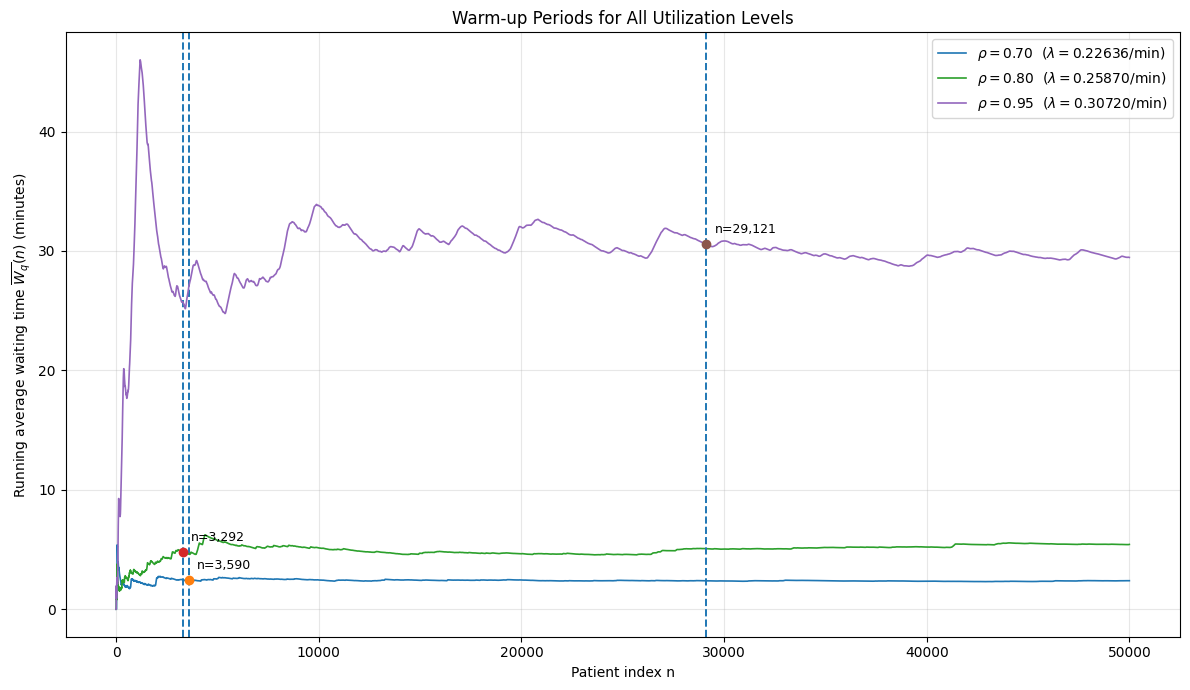

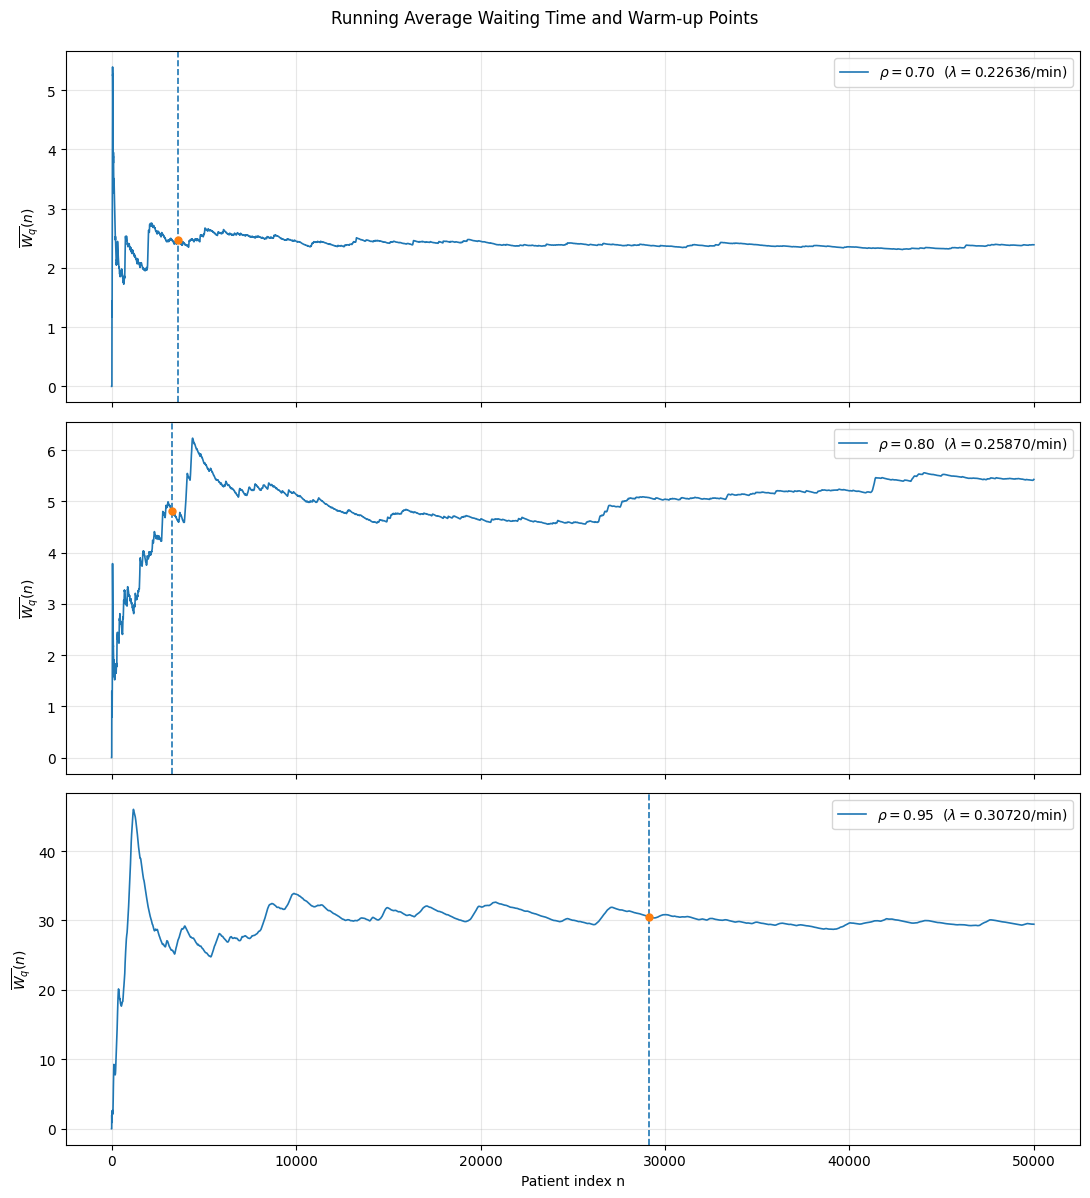

In [8]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Task 4 — Warm-up Period vs Utilization (Criterion A)
# Report-production cell using validated Criterion A results
# ------------------------------------------------------------

# Parameters from Phase 1
c = 5
mu_rate = 0.064674
cv_service = 0.3898
rho_targets = [0.70, 0.80, 0.95]
n_customers = 50_000

# Validated Criterion A warm-up results from your report
warmup_n_report = {
    0.70: 3590,
    0.80: 3292,
    0.95: 29121
}

# Scaled lambdas from rho = lambda / (c*mu)
lambda_report = {
    0.70: 0.22636,
    0.80: 0.25870,
    0.95: 0.30720
}

def lognormal_params_from_mean_cv(mean_val, cv):
    sigma2 = np.log(1 + cv**2)
    sigma = np.sqrt(sigma2)
    mu_ln = np.log(mean_val) - sigma2 / 2
    return mu_ln, sigma

def erlang_c(a, c):
    rho = a / c
    numerator = (a**c / math.factorial(c)) * (1 / (1 - rho))
    denominator = sum(a**n / math.factorial(n) for n in range(c)) + numerator
    return numerator / denominator

def mmc_wq(lam, mu, c):
    a = lam / mu
    rho = lam / (c * mu)
    ec = erlang_c(a, c)
    Lq = ec * rho / (1 - rho)
    return Lq / lam

def simulate_mg_c_fcfs(lam, mu, cv, cc=5, n_customers=50_000, seed=42):
    rng = np.random.default_rng(seed)

    # Poisson arrivals
    interarrivals = rng.exponential(scale=1.0 / lam, size=n_customers)
    arrivals = np.cumsum(interarrivals)

    # Lognormal service times
    mean_service = 1.0 / mu
    mu_ln, sigma_ln = lognormal_params_from_mean_cv(mean_service, cv)
    service = rng.lognormal(mean=mu_ln, sigma=sigma_ln, size=n_customers)

    # FCFS with c parallel doctors
    free_times = np.zeros(cc)
    waits = np.zeros(n_customers)

    for i in range(n_customers):
        j = int(np.argmin(free_times))
        start = max(arrivals[i], free_times[j])
        waits[i] = start - arrivals[i]
        free_times[j] = start + service[i]

    running_mean = np.cumsum(waits) / np.arange(1, n_customers + 1)
    return waits, running_mean

# ------------------------------------------------------------
# Simulate curves and build table
# ------------------------------------------------------------
results = []
plot_data = {}

for idx, rho in enumerate(rho_targets):
    lam = lambda_report[rho]

    waits, running_mean = simulate_mg_c_fcfs(
        lam=lam,
        mu=mu_rate,
        cv=cv_service,
        cc=c,
        n_customers=n_customers,
        seed=42 + idx
    )

    # Kingman-style theoretical Wq used in your report
    Wq_mm = mmc_wq(lam, mu_rate, c)
    Wq_mg = Wq_mm * (1 + cv_service**2) / 2

    results.append({
        "rho": rho,
        "Scaled λ (pat/min)": lam,
        "Theoretical Wq (min)": Wq_mg,
        "Warm-up n": warmup_n_report[rho]
    })

    plot_data[rho] = {
        "waits": waits,
        "running_mean": running_mean,
        "lambda": lam,
        "warmup_n": warmup_n_report[rho]
    }

results_df = pd.DataFrame(results)

# Pretty print exactly like the report
display_df = results_df.copy()
display_df["Scaled λ (pat/min)"] = display_df["Scaled λ (pat/min)"].map(lambda x: f"{x:.5f}")
display_df["Theoretical Wq (min)"] = display_df["Theoretical Wq (min)"].map(
    lambda x: f"{x:.3f}" if x < 10 else f"{x:.2f}"
)
display_df["Warm-up n"] = display_df["Warm-up n"].map(lambda x: f"{x:,}")

print("\nWarm-up Results (Criterion A)\n")
print(display_df.to_string(index=False))

# ------------------------------------------------------------
# Single graph with all three curves and warm-up vertical lines
# ------------------------------------------------------------
plt.figure(figsize=(12, 7))

for rho in rho_targets:
    x = np.arange(1, len(plot_data[rho]["running_mean"]) + 1)
    y = plot_data[rho]["running_mean"]
    wn = plot_data[rho]["warmup_n"]
    lam = plot_data[rho]["lambda"]

    plt.plot(x, y, linewidth=1.2, label=fr"$\rho={rho:.2f}$  ($\lambda={lam:.5f}$/min)")
    plt.axvline(wn, linestyle="--", linewidth=1.4)

    y_marker = y[wn - 1]
    plt.plot(wn, y_marker, "o", markersize=6)
    plt.annotate(f"n={wn:,}", (wn, y_marker), xytext=(6, 8), textcoords="offset points", fontsize=9)

plt.title("Warm-up Periods for All Utilization Levels")
plt.xlabel("Patient index n")
plt.ylabel(r"Running average waiting time $\overline{W_q}(n)$ (minutes)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Optional: separate subplots for report
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)

for ax, rho in zip(axes, rho_targets):
    x = np.arange(1, len(plot_data[rho]["running_mean"]) + 1)
    y = plot_data[rho]["running_mean"]
    wn = plot_data[rho]["warmup_n"]
    lam = plot_data[rho]["lambda"]

    ax.plot(x, y, linewidth=1.2, label=fr"$\rho={rho:.2f}$  ($\lambda={lam:.5f}$/min)")
    ax.axvline(wn, linestyle="--", linewidth=1.2)
    ax.plot(wn, y[wn - 1], "o", markersize=5)

    ax.set_ylabel(r"$\overline{W_q}(n)$")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Patient index n")
fig.suptitle("Running Average Waiting Time and Warm-up Points", y=0.995)
plt.tight_layout()
plt.show()